In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.preprocessing import StandardScaler
import numpy as np


In [2]:
df = pd.read_csv("thyroid_dataset.csv")

In [3]:
df.head()


,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,goitre,tumor,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured,Outlier_label
0,0.45,1,0,0,0,0,0,0,0,0,...,0,0,0,0,61.0,6.0,23.0,87.0,26.0,o
1,0.61,0,0,0,0,1,0,0,0,0,...,0,0,0,0,29.0,15.0,61.0,96.0,64.0,o
2,0.16,0,1,0,0,0,0,0,0,0,...,0,1,0,0,29.0,19.0,58.0,103.0,56.0,o
3,0.85,0,0,0,0,0,0,0,0,0,...,0,0,0,0,114.0,3.0,24.0,61.0,39.0,o
4,0.75,1,0,0,0,0,0,0,0,0,...,0,0,0,0,49.0,3.0,5.0,116.0,4.0,o


In [7]:
X = df.drop("Outlier_label",axis=1)
y = df["Outlier_label"]
df.shape

(6916, 22)

In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [14]:
from sklearn.ensemble import IsolationForest 
clf = IsolationForest(n_estimators = 200 ,contamination = 'auto' ,random_state=42)
#combination can be any percentage if known 0.03 

In [16]:
labels = clf.fit_predict(X_scaled)

In [17]:
labels

array([ 1,  1, -1, ...,  1,  1,  1], shape=(6916,))

In [18]:
# Visulaize 
from sklearn.decomposition import PCA 
pca = PCA(n_components = 2 )

X_pca = pca.fit_transform(X_scaled)


Text(0, 0.5, 'PC2')

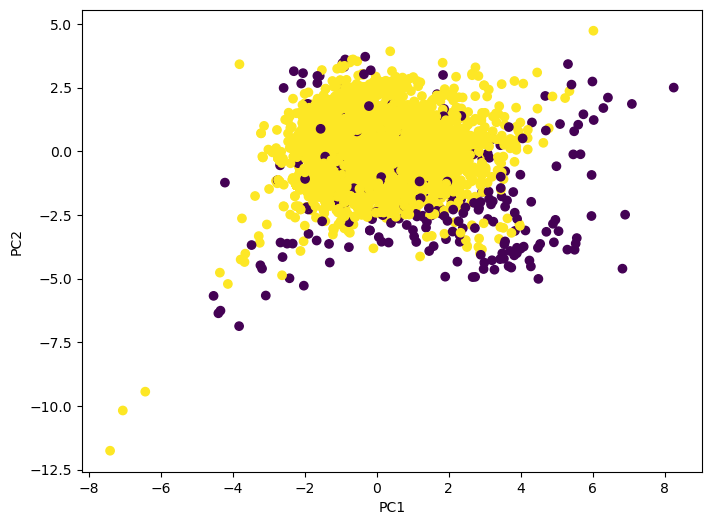

In [19]:
plt.figure(figsize=(8,6))

plt.scatter(X_pca[:,0],X_pca[:,1], c = labels )
plt.xlabel("PC1")
plt.ylabel("PC2")

In [22]:
n_outlier = np.sum(labels == -1)
n_normal = np.sum(labels == 1)
print("No. of outlier ",n_outlier)
print("No. of normal points ",n_normal)

No. of outlier  270
No. of normal points  6646



## LOF

In [23]:
from sklearn.neighbors import LocalOutlierFactor


In [27]:
neighbs = LocalOutlierFactor(contamination=0.03)
labels = neighbs.fit_predict(X_scaled)

Text(0, 0.5, 'PC2')

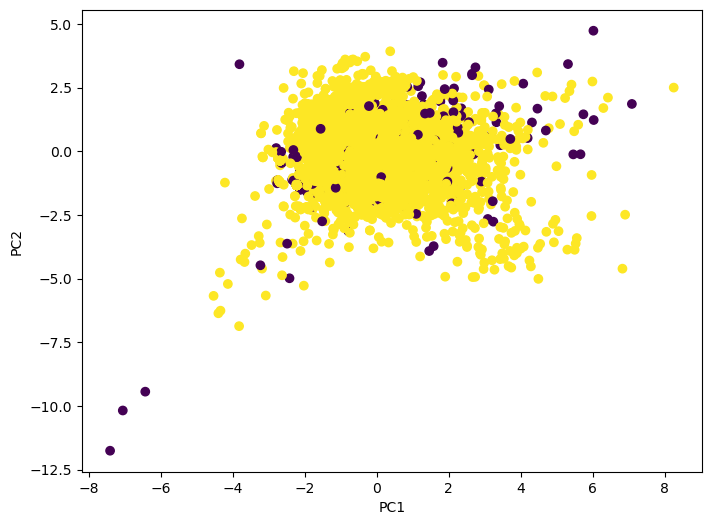

In [28]:
plt.figure(figsize=(8,6))

plt.scatter(X_pca[:,0],X_pca[:,1], c = labels )
plt.xlabel("PC1")
plt.ylabel("PC2")

In [29]:
n_outlier = np.sum(labels == -1)
n_normal = np.sum(labels == 1)
print("No. of outlier ",n_outlier)
print("No. of normal points ",n_normal)

No. of outlier  208
No. of normal points  6708
